# Arithmetic Operations on Images

This notebook demonstrates addition, subtraction, multiplication, and division on `selfie.jpg`.
The input image is converted to grayscale, and arithmetic operations are applied using simple operand images:

- A constant intensity offset image for addition and subtraction
- A smooth horizontal scale map for multiplication and division


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def load_image_unicode(image_path, flags=cv2.IMREAD_COLOR):
    image_bytes = np.fromfile(str(image_path), dtype=np.uint8)
    image = cv2.imdecode(image_bytes, flags)
    if image is None:
        raise ValueError(f'Failed to load image: {image_path}')
    return image


image_path = Path('selfie.jpg')
results_dir = Path('results')
results_dir.mkdir(exist_ok=True)

image_bgr = load_image_unicode(image_path)
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

print(f'Image shape: {image_gray.shape}')

Image shape: (1080, 1920)


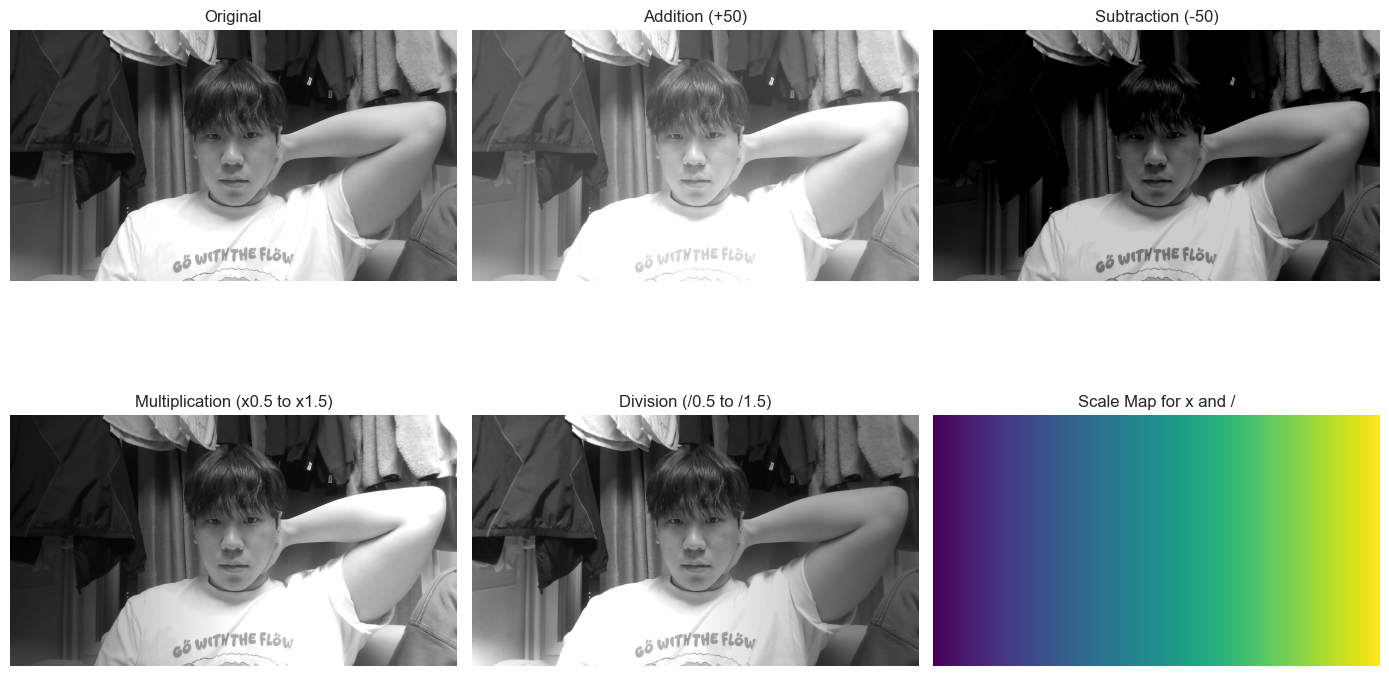

In [3]:
offset_value = 50
offset_image = np.full_like(image_gray, offset_value)

scale_row = np.linspace(0.5, 1.5, image_gray.shape[1], dtype=np.float32)
scale_map = np.tile(scale_row, (image_gray.shape[0], 1))

addition = np.clip(image_gray.astype(np.int16) + offset_image.astype(np.int16), 0, 255).astype(np.uint8)
subtraction = np.clip(image_gray.astype(np.int16) - offset_image.astype(np.int16), 0, 255).astype(np.uint8)
multiplication = np.clip(image_gray.astype(np.float32) * scale_map, 0, 255).astype(np.uint8)
division = np.clip(image_gray.astype(np.float32) / scale_map, 0, 255).astype(np.uint8)

images = {
    'Original': image_gray,
    'Addition (+50)': addition,
    'Subtraction (-50)': subtraction,
    'Multiplication (x0.5 to x1.5)': multiplication,
    'Division (/0.5 to /1.5)': division,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (title, img) in zip(axes.ravel(), images.items()):
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis('off')

axes[1, 2].imshow(scale_map, cmap='viridis')
axes[1, 2].set_title('Scale Map for x and /')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

fig.savefig(results_dir / 'arithmetic_operations.png', dpi=180, bbox_inches='tight')

In [4]:
def describe_image(name, image):
    print(f"{name:<28} min={image.min():>3} max={image.max():>3} mean={image.mean():>8.2f}")


for name, image in images.items():
    describe_image(name, image)

Original                     min=  0 max=255 mean=  111.42
Addition (+50)               min= 50 max=255 mean=  155.59
Subtraction (-50)            min=  0 max=205 mean=   66.10
Multiplication (x0.5 to x1.5) min=  0 max=255 mean=  115.22
Division (/0.5 to /1.5)      min=  0 max=255 mean=  109.89
